In [1]:
from pathlib import Path
from kaggle import api
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from fastai.tabular.core import add_datepart
from fastai.tabular.core import TabularPandas
from fastai.tabular.core import Categorify, FillMissing
from fastai.tabular.core import cont_cat_split
from sklearn.tree import plot_tree

---
# Data Preprocessing 

In [2]:
data_dir = Path('datasets')
data_dir.mkdir(exist_ok=True, parents=False)

# Kaggle creds should already be saved to file ~/.kaggle/kaggle.json
# if not, check FastAI, (in book chapter 09 at time of writing), for steps to set up Kaggle. 
def get_bulldozers_data(data_dir:Path) -> Path:
    comp = 'bluebook-for-bulldozers'
    save_path = data_dir / comp
    if not save_path.exists():
        save_path.mkdir(exist_ok=True, parents=False)
        api.competition_download_cli(comp, path=save_path)
        shutil.unpack_archive(str(save_path.resolve()/f'{comp}.zip'), str(save_path))
    return save_path

def preprocess_data(train_data_path:Path, test_data_path:Path) -> TabularPandas:
    df = pd.read_csv(train_data_path, low_memory=False)
    df_test = pd.read_csv(test_data_path, low_memory=False)
    
    dep_var = 'SalePrice'
    fastai_preprocessing = [Categorify, FillMissing]
    sizes = 'Large','Large / Medium','Medium','Small','Mini','Compact'
    
    df['ProductSize'] = df['ProductSize'].astype('category')
    df['ProductSize'] = df['ProductSize'].cat.set_categories(sizes, ordered=True)
    df[dep_var] = np.log(df[dep_var])
    
    df = add_datepart(df, 'saledate')
    df_test = add_datepart(df_test, 'saledate')
    
    train_val_split_condition = (df.saleYear<2011) | (df.saleMonth<10)
    train_idx = np.where( train_val_split_condition)[0]
    valid_idx = np.where(~train_val_split_condition)[0]
    train_val_splits = (list(train_idx),list(valid_idx))
    
    cont,cat = cont_cat_split(df, 1, dep_var=dep_var)

    to = TabularPandas(df, fastai_preprocessing, cat, cont, 
                       y_names=dep_var, splits=train_val_splits)
    return to

In [3]:
save_path = get_bulldozers_data(data_dir)
print(f'Saved dataset to {str(save_path.resolve())} files:\n{[str(p.name) for p in save_path.iterdir()]}')

Saved dataset to /Users/seanmcmahon/repos/sean-mcmahon.github.io/notebooks/datasets/bluebook-for-bulldozers files:
['random_forest_benchmark_test.csv', 'Valid.csv', 'bluebook-for-bulldozers.zip', 'median_benchmark.csv', 'Valid.zip', 'TrainAndValid.7z', 'Test.csv', 'Train.7z', 'ValidSolution.csv', 'Machine_Appendix.csv', 'Valid.7z', 'Data Dictionary.xlsx', 'TrainAndValid.csv', 'Train.zip', 'TrainAndValid.zip']


In [4]:
train_df_path = save_path / 'TrainAndValid.csv'
test_df_path = save_path / 'Test.csv'
tabula_pandas = preprocess_data(train_df_path, test_df_path)

/Users/seanmcmahon/miniconda3/envs/sean-mcmahon.github.io/lib/python3.12/site-packages/fastai/tabular/core.py:23: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df[date_field] = pd.to_datetime(df[date_field], infer_datetime_format=True)
/Users/seanmcmahon/miniconda3/envs/sean-mcmahon.github.io/lib/python3.12/site-packages/fastai/tabular/core.py:23: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df[date_field] = pd.to_datetime(df[date_field], infer_datetime_format=True)
/Users/seanmcmahon/miniconda3/envs/sean-mcmahon.github.io/lib/python3.12/site-packages/fas

Check attributes are the same as Lesson 09 of Fastbook Tabular Data.

In [5]:
assert len(tabula_pandas.train) == 404710
assert len(tabula_pandas.valid) == 7988
expected_product_sizes = ['#na#', 'Large', 'Large / Medium', 'Medium', 'Small', 'Mini', 'Compact']
assert tabula_pandas.classes['ProductSize'] == expected_product_sizes
assert tabula_pandas.items.iloc[2,:].SalesID == 1139249
tabula_pandas.items.head()

,SalesID,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,fiModelDesc,...,saleDayofyear,saleIs_month_end,saleIs_month_start,saleIs_quarter_end,saleIs_quarter_start,saleIs_year_end,saleIs_year_start,saleElapsed,auctioneerID_na,MachineHoursCurrentMeter_na
0,1139246,11.097410,999089,3157,121,3.0,2004,68.0,2,963,...,320,1,1,1,1,1,1,1.163635e+09,1,1
1,1139248,10.950807,117657,77,121,3.0,1996,4640.0,2,1745,...,86,1,1,1,1,1,1,1.080259e+09,1,1
2,1139249,9.210340,434808,7009,121,3.0,2001,2838.0,1,336,...,57,1,1,1,1,1,1,1.077754e+09,1,1
3,1139251,10.558414,1026470,332,121,3.0,2001,3486.0,1,3716,...,139,1,1,1,1,1,1,1.305763e+09,1,1
4,1139253,9.305651,1057373,17311,121,3.0,2007,722.0,3,4261,...,204,1,1,1,1,1,1,1.248307e+09,1,1


In [6]:
train_x,train_y = tabula_pandas.train.xs,tabula_pandas.train.y
valid_xs,valid_y = tabula_pandas.valid.xs,tabula_pandas.valid.y

In [7]:
# Obtained from Fastbook chapter 09, on feature importance
np.random.seed(42)
reduced_feature_ids = {57: 'YearMade', 6: 'ProductSize', 30: 'Coupler_System', 7: 'fiProductClassDesc', 32: 'Hydraulics_Flow'}
assert all([fname == train_x.columns[fid] for fid, fname in reduced_feature_ids.items()])
number_samples = 1000
r_subset_ids = np.random.choice(np.arange(0, train_x.shape[0]), size=number_samples)
subset_feature_ids = list(reduced_feature_ids.keys())
small_train_x, small_train_y = train_x.iloc[r_subset_ids,subset_feature_ids], train_y.iloc[r_subset_ids]
small_valid_xs, small_valid_y = valid_xs.iloc[:, subset_feature_ids], valid_y 

In [8]:
small_train_x.head()

,YearMade,ProductSize,Coupler_System,fiProductClassDesc,Hydraulics_Flow
123047,1988,4,0,8,0
147958,1998,0,0,54,0
133021,1996,4,0,7,0
366956,2004,3,0,47,0
260296,1989,0,1,40,3


In [9]:
train_x.describe()

,UsageBand,fiModelDesc,fiBaseModel,fiSecondaryDesc,fiModelSeries,fiModelDescriptor,ProductSize,fiProductClassDesc,state,ProductGroup,...,auctioneerID,YearMade,MachineHoursCurrentMeter,saleYear,saleMonth,saleWeek,saleDay,saleDayofweek,saleDayofyear,saleElapsed
count,404710.000000,404710.000000,404710.000000,404710.000000,404710.000000,404710.000000,404710.000000,404710.000000,404710.000000,404710.000000,...,404710.000000,404710.000000,4.047100e+05,404710.000000,404710.000000,404710.000000,404710.000000,404710.000000,404710.000000,4.047100e+05
mean,0.403603,1694.510563,562.059774,37.789019,9.189074,12.269183,1.430805,32.288293,23.408134,3.726488,...,6.376904,1898.853058,1.234279e+03,2004.185483,6.202283,25.307035,16.208295,2.604576,173.858556,1.093736e+09
std,0.932001,1278.566741,471.820397,38.966726,27.010056,29.165079,1.746535,22.601014,15.723241,1.726400,...,16.716217,292.282458,1.647326e+04,5.801299,3.396637,14.678878,8.443734,1.416460,102.735489,1.825096e+08
min,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,1000.000000,0.000000e+00,1989.000000,1.000000,1.000000,1.000000,0.000000,1.000000,6.009984e+08
25%,0.000000,640.000000,208.000000,0.000000,0.000000,0.000000,0.000000,11.000000,9.000000,2.000000,...,1.000000,1985.000000,0.000000e+00,2000.000000,3.000000,12.000000,9.000000,2.000000,81.000000,9.719136e+08
50%,0.000000,1413.000000,408.000000,31.000000,0.000000,0.000000,0.000000,35.000000,20.000000,4.000000,...,2.000000,1995.000000,0.000000e+00,2006.000000,6.000000,24.000000,16.000000,3.000000,162.000000,1.145491e+09
75%,0.000000,2316.000000,706.000000,59.000000,0.000000,0.000000,3.000000,52.000000,38.000000,5.000000,...,4.000000,2000.000000,0.000000e+00,2009.000000,9.000000,39.000000,23.000000,3.000000,266.000000,1.238544e+09
max,3.000000,5059.000000,1961.000000,177.000000,123.000000,140.000000,6.000000,74.000000,53.000000,6.000000,...,99.000000,2014.000000,2.483300e+06,2012.000000,12.000000,53.000000,31.000000,6.000000,365.000000,1.335571e+09


Test on Sklearn to ensure all worky

In [10]:
sk_tree = DecisionTreeRegressor(max_leaf_nodes=4)
sk_tree.fit(small_train_x, small_train_y)

DecisionTreeRegressor(max_leaf_nodes=4)

In [11]:
t = sk_tree.tree_.value
t.shape

(7, 1, 1)

[Text(0.6, 0.875, 'Hydraulics_Flow <= 0.5\nsquared_error = 0.49234\nsamples = 1000\nvalue = 10.08883'),
 Text(0.4, 0.625, 'YearMade <= 1981.5\nsquared_error = 0.41244\nsamples = 883\nvalue = 10.21179'),
 Text(0.2, 0.375, 'squared_error = 0.25737\nsamples = 190\nvalue = 9.74001'),
 Text(0.6, 0.375, 'fiProductClassDesc <= 13.5\nsquared_error = 0.3772\nsamples = 693\nvalue = 10.34113'),
 Text(0.4, 0.125, 'squared_error = 0.21654\nsamples = 264\nvalue = 9.9997'),
 Text(0.8, 0.125, 'squared_error = 0.36018\nsamples = 429\nvalue = 10.55125'),
 Text(0.8, 0.625, 'squared_error = 0.12011\nsamples = 117\nvalue = 9.16085')]

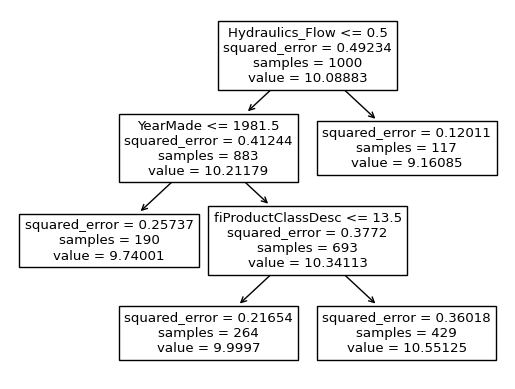

In [12]:
from sklearn.tree import plot_tree
plot_tree(sk_tree, feature_names=small_train_x.columns, precision=5)

In [13]:
??sk_tree.tree_.predict

Signature: sk_tree.tree_.predict(X)
Docstring: Predict target for X.
Type:      method

---
# Decision Tree  

In [14]:
from abc import ABC
from abc import abstractmethod

class Metrics():
    @staticmethod
    def mse(y_pred:np.ndarray, y_gt:np.ndarray) -> np.float64:
        return ((y_pred - y_get)**2).mean()

    @staticmethod
    def root_mse(y_pred:np.ndarray, y_gt:np.ndarray) -> np.float64:
        return np.sqrt(Metrics.mse(y_pred, y_gt))

class DecisionTreeBase(ABC):
    def __init__(self, min_samples_leaf:int=1, max_leaf_nodes:int|None=None):
        self.min_samples_leaf = min_samples_leaf
        self.max_leaf_nodes = max_leaf_nodes

    @abstractmethod
    def fit(self, X, y):
        # X has shape (n_samples, n_features)
        # y has shape (n_samples,) or (n_samples, n_outputs)
        pass
        # While num_nodes < max_nodes:
        # select best feature base on heuristic
        # find best threshold of heuristic using Gini metric (MSE/L2)
        # Loop again 

    @abstractmethod
    def predict(self, X):
        # X of shape (n_samples, n_features)
        pass


In [15]:
from typing import NewType
from dataclasses import dataclass

from sklearn.tree._tree import Tree

class SkLearnDecisionTree(DecisionTreeBase):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.model = DecisionTreeRegressor(
            min_samples_leaf=self.min_samples_leaf,
            max_leaf_nodes=self.max_leaf_nodes)

    def fit(self, X, y):
        self.model.fit(X,y)

    def predict(self, X) -> np.ndarray:
        return self.model.predict(X)

sklean_dt = SkLearnDecisionTree()
sklean_dt.fit(small_train_x, small_train_y)
sk_y_pred_valid = sklean_dt.predict(small_valid_xs)

## Inference Code

In [16]:
# %debug 
# TreeNode_ = NewType("TreeNode", object)
@dataclass
class TreeNode():
    # Data for this child from X[:, feature[i]] <= threshold[i]
    children_left_id: int | None = None
    # Data for this child X[:, feature[i]] > threshold[i]
    children_right_id: int | None = None
    feature_id:int = 0.
    threshold:float = 0.
    values: float | None = None
    index:int = 0


class PredictSkLearnDecisionTree(SkLearnDecisionTree):

    def _get_node(self,index:int) -> TreeNode:
        tree = self.model.tree_
        tn = TreeNode(
            children_left_id=tree.children_left[index],
            children_right_id=tree.children_right[index],
            feature_id=tree.feature[index],
            threshold=tree.threshold[index],
            values=tree.value[index],
            index=index
        )
        return tn

    def predict(self, Xdata: np.ndarray | pd.DataFrame) -> np.ndarray:
        if isinstance(Xdata, pd.DataFrame):
            Xdata = Xdata.to_numpy(copy=True)
        # My own re-implementation of predict using Sci-kit's tree.
        # Xdata of shape (n_samples, n_features)
        # Y (returned) of shape (n_samples,) or (n_samples, n_outputs)
        y_pred = np.zeros((Xdata.shape[0]))
        x_ids = np.arange(Xdata.shape[0])
        stack = [[self._get_node(0), x_ids]] # stack of [Node:TreeNode, data_at_node:np.ndarray]
        # print(f'{self.model.tree_.node_count} nodes and {self.model.tree_.max_depth} depth to traverse')
        num_leaf_node_samples = 0
        leaf_node_samples = set()
        while stack:
            node, data_ids_at_node = stack.pop()
            is_split_node = node.children_left_id != node.children_right_id
            
            # exp_samples = self.model.tree_.n_node_samples[node.index]
            # split_n_str = 'Split' if is_split_node else 'Leaf'
            # print(f'{split_n_str.ljust(5)} node ({node.index}) split {train_x.columns[node.feature_id]} ({node.feature_id}), '\
            #      f'threshold: {node.threshold}, samples {data_ids_at_node.shape[0]} '\
            #      f'({len(np.unique(data_ids_at_node))} unqiue) has values {node.values}')            

            if is_split_node:
                left_ids = np.where(Xdata[data_ids_at_node, node.feature_id] <= node.threshold)[0]
                right_ids = np.where(Xdata[data_ids_at_node, node.feature_id] > node.threshold)[0]
                data_left_ids = data_ids_at_node[left_ids]
                data_right_ids = data_ids_at_node[right_ids]
                assert len(data_ids_at_node) == len(
                    data_right_ids) + len(data_left_ids),'incorrect number of indexes'
                assert set(tuple(data_right_ids)).isdisjoint(
                    set(tuple(data_left_ids))), 'Set index overlap between left and right sides'
                stack.append([self._get_node(node.children_left_id), data_left_ids])
                stack.append([self._get_node(node.children_right_id), data_right_ids])
            else:
                y_pred[data_ids_at_node] = node.values.squeeze()

        return y_pred

max_leaf_nodes = 6

sklean_dt = SkLearnDecisionTree(max_leaf_nodes=max_leaf_nodes)
sklean_dt.fit(small_train_x, small_train_y)
sk_y_pred_valid = sklean_dt.predict(small_valid_xs)

sklearn_mypred_dt = PredictSkLearnDecisionTree(max_leaf_nodes=max_leaf_nodes)
sklearn_mypred_dt.fit(small_train_x, small_train_y)
mypred_y_pred_valid = sklearn_mypred_dt.predict(small_valid_xs)
sk_pred_valid = sklearn_mypred_dt.model.predict(small_valid_xs)

Check prediction matches scikit learn predicts output

In [17]:
def count_num_pred_values(value, pred_sk=sk_pred_valid, pred_me=mypred_y_pred_valid):
    c_sk = np.isclose(pred_sk,value).sum()
    c_me = np.isclose(pred_me,value).sum()
    message = f'For {str(value).ljust(18)}; Sklearn pred has {str(c_sk).ljust(4)} values, my predictor has {c_me} values'
    assert c_sk == c_me, message

un_val = set(tuple(np.unique(mypred_y_pred_valid).tolist() + np.unique(sk_pred_valid).tolist()))
for v in un_val: 
    count_num_pred_values(v, pred_sk=sk_pred_valid, pred_me=mypred_y_pred_valid)
print('Number of prediction values match!')
assert np.allclose(mypred_y_pred_valid, sk_pred_valid), f'Prediction values are not all close'
print('Prediction values are all close!')

Number of prediction values match!
Prediction values are all close!


[Text(0.6352645279370126, 0.9814814814814815, 'fiModelSeries <= 0.5\nsquared_error = 0.49234\nsamples = 1000\nvalue = 10.08883'),
 Text(0.3295848477668421, 0.9444444444444444, 'UsageBand <= 1981.5\nsquared_error = 0.41244\nsamples = 883\nvalue = 10.21179'),
 Text(0.11184660896777664, 0.9074074074074074, 'UsageBand <= 1971.5\nsquared_error = 0.25737\nsamples = 190\nvalue = 9.74001'),
 Text(0.07745342526037846, 0.8703703703703703, 'fiModelDesc <= 4.5\nsquared_error = 0.21646\nsamples = 107\nvalue = 9.60163'),
 Text(0.046159112023861915, 0.8333333333333334, 'fiSecondaryDesc <= 32.5\nsquared_error = 0.23339\nsamples = 89\nvalue = 9.64661'),
 Text(0.020341303603735757, 0.7962962962962963, 'fiSecondaryDesc <= 20.5\nsquared_error = 0.26999\nsamples = 41\nvalue = 9.78251'),
 Text(0.014864798787345363, 0.7592592592592593, 'fiSecondaryDesc <= 13.0\nsquared_error = 0.14835\nsamples = 30\nvalue = 9.67975'),
 Text(0.011735367463693707, 0.7222222222222222, 'fiSecondaryDesc <= 11.5\nsquared_error = 0

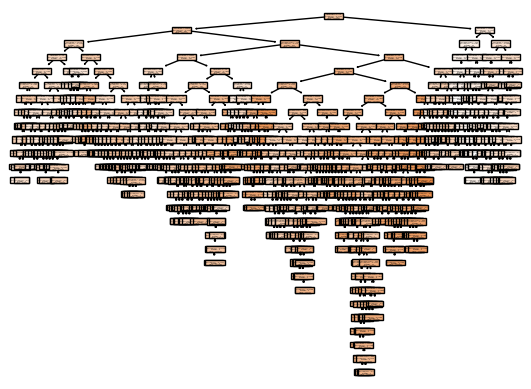

In [18]:
max_leaf_nodes = None

sklean_dt = SkLearnDecisionTree(max_leaf_nodes=max_leaf_nodes)
# sklean_dt.fit(train_x.iloc[:500,...],train_y.iloc[:500])
sklean_dt.fit(small_train_x, small_train_y)
sk_y_pred_valid = sklean_dt.predict(small_valid_xs)
imps = sklean_dt.model.tree_.impurity
features = sklean_dt.model.tree_.feature

# for i, imp in enumerate(imps):
#     print(f'At Node {i}; impurity {imp:.5f}, feature {features[i]}')
plot_tree(sklean_dt.model,feature_names=train_x.columns, filled=True, precision=5)


## Fit / Training Code

In [19]:
from typing import NewType

TreeNode_ = NewType("TreeNode", object)

@dataclass
class TreeNode():
    # Data for this child from X[:, feature[i]] <= threshold[i]
    children_left_id: TreeNode_ | None = None
    # Data for this child X[:, feature[i]] > threshold[i]
    children_right_id: TreeNode_ | None = None
    feature_id:int = 0.
    threshold:float = 0.
    values: float | None = None
    index:int = 0

class MyDecisionTree(DecisionTreeBase):
    def fit(self, Xdata, y):
        if isinstance(Xdata, pd.DataFrame):
            Xdata = Xdata.to_numpy(copy=True)
        # X has shape (n_samples, n_features)
        # y has shape (n_samples,) or (n_samples, n_outputs)
        
        # Use current nodes impurity score
        # Loop over features
            # For each feature, loop over each value, using it as a threshold
                # At each threshold, record the best impurity and threshold value, and mean value (for regression)
            # Aggregate impurity for this feature to get a score
        # If there's an impurity reduction, select feature with lowest score, and use stored threshold. 

    def _find_feature_and_split(self, Xdata_at_split:np.ndarray, y:np.ndarray) -> tuple[float, float, int]:
        min_impurity = None
        min_impurity_threshold = None
        for feature_id in range(Xdata_at_split.shape[1]):
            feature_min_impurity, feature_min_impurity_threshold = self._find_feature_impurity(Xdata_at_split[:,feature_id], y)
            # feature_min_impurity = ((y - y.mean())**2).mean()
            print(f'For feature id {feature_id}, impurity {feature_min_impurity:.5f}, threshold {feature_min_impurity_threshold:.2f}')
            if min_impurity is None or feature_min_impurity < min_impurity:
                min_impurity = feature_min_impurity
                min_impurity_threshold = feature_min_impurity_threshold
            
        return min_impurity, min_impurity_threshold, feature_id

    def _find_feature_impurity(self, featureX:np.ndarray, y_values:np.ndarray):
        unique_values = np.unique(featureX)
        min_impurity = None
        min_impurity_threshold = None
        # want to start with 0th uv and end with nth uv
        # but in between use the differences instead 
        # so for ith = (ith + (i-1)th) / 2
        threshold_values = unique_values # [(unique_values[i] + unique_values[i+1]) / 2 for i in range(0,len(unique_values)-1)]
        # threshold_values.extend([unique_values[0], unique_values[-1]])
        # import pdb; pdb.set_trace()
        # print(f'Feature, {featureX.shape[0]} values, mean {y_values.mean():.5f}, mse {((y_values-y_values.mean())**2).mean():.5f}')
        for c, threshold in enumerate(threshold_values):
            # import pdb; pdb.set_trace()
            q_left_ids  = np.where(featureX <= threshold)[0]
            q_right_ids = np.where(featureX >  threshold)[0]

            num_vals = featureX.shape[0]
            # G(Q_m, Theta) in scikit equations
            left_mse = self._loss_for_split(y_values, q_left_ids)
            right_mse = self._loss_for_split(y_values, q_right_ids)
            split_impurity = len(q_left_ids)/num_vals * left_mse + len(
                q_right_ids)/num_vals * right_mse
            # print(f'For threshold {threshold}, impurity {split_impurity:.5f}. {len(q_left_ids)} Left mse {left_mse:.5f}. '\
            #       f'{len(q_right_ids)} Right mse {right_mse:.5f}')
            if min_impurity is None or split_impurity < min_impurity:
                min_impurity = split_impurity
                if c < len(threshold_values)-1:
                    min_impurity_threshold = (threshold + threshold_values[c+1]) / 2
                else:
                    # import pdb; pdb.set_trace()
                    min_impurity_threshold = (threshold + threshold_values[c-1]) / 2
        return min_impurity, min_impurity_threshold

    def _loss_for_split(self, y_gt:np.ndarray, y_pred_indices:list[int]) -> float:
        # H(Q_m) in the scikit equations
        if len(y_pred_indices) > 0:
            y_qm = y_gt[y_pred_indices]
            y_pred = y_qm.mean()
            mse = ((y_qm - y_pred)**2).mean()
        else:
            mse = 0
        return mse
                                  
    def predict(self, X):
        # X of shape (n_samples, n_features)
        pass

In [20]:
# Test find threshold with Coupler_System (train_x.columns[30])
assert small_train_x.columns[4] == 'Hydraulics_Flow'
m_dt =  MyDecisionTree()
train_x_hydrolics = small_train_x.iloc[:,4].to_numpy(copy=True)
train_y_hydrolics = small_train_y.to_numpy(copy=True)
min_impurity, min_impurity_threshold = m_dt._find_feature_impurity(train_x_hydrolics, train_y_hydrolics)
print(f'For Hydraulics_Flow, found threshold of {min_impurity_threshold:.2f} with impurity {min_impurity:.5f}')
expected_impurity_left = 0.41244
expected_n_left = 883
expected_impurity_right = 0.12011
expected_n_right = 117
n_ = expected_n_left + expected_n_right
assert n_ == 1000 # sanity check for me, not the tests
# expected_impurity = 0.48206
expected_impurity = expected_n_left/n_ * expected_impurity_left + expected_n_right / n_ * expected_impurity_right
assert min_impurity_threshold == 0.5, f'Threshold wrong, expected 0.5, got {min_impurity_threshold}'
# TODO update expected value for small_train_x dataset
assert np.isclose(min_impurity, expected_impurity), f'expected {expected_impurity} got {min_impurity:.5f}'
print('Successfully selected threshold, and got impurity for single feature')

For Hydraulics_Flow, found threshold of 0.50 with impurity 0.37824
Successfully selected threshold, and got impurity for single feature


In [24]:
# Test find feature, at root of tree it should be Coupler_System (small_train_x.columns[2]).
expected_feature_id = 4 # Hydrolic flow for small_train_x

assert small_train_x.columns[expected_feature_id] == 'Hydraulics_Flow'
m_dt =  MyDecisionTree()
train_x_feature_select = small_train_x.to_numpy(copy=True)
train_y_feature_select = small_train_y.to_numpy(copy=True)
min_impurity, min_impurity_threshold, feature_id = m_dt._find_feature_and_split(train_x_feature_select, train_y_feature_select)
print(f'Got feature {feature_id}, min_impurity {min_impurity:.6f}, threshold {min_impurity_threshold}')
expected_threshold = 0.5 # 0.5  Hydrolic flow for small_train_x
assert feature_id == expected_feature_id, (
    f'Expected id {expected_feature_id} ({small_train_x.columns[expected_feature_id]}), '\
    f'got {feature_id} ({small_train_x.columns[feature_id]})')
assert min_impurity_threshold == expected_threshold

For feature id 0, impurity 0.44755, threshold 1972.50
For feature id 1, impurity 0.43646, threshold 0.50
For feature id 2, impurity 0.37824, threshold 0.50
For feature id 3, impurity 0.45954, threshold 46.50
For feature id 4, impurity 0.37824, threshold 0.50
Got feature 4, min_impurity 0.378237, threshold 0.5
